# Testing
bfs_hotelgaeste_stadt_zuerich_od1104
## Hotelbetriebe in der Stadt Zürich
Datum: 13.12.2024

### Kurzbeschreibung
Diese Daten beinhalten Zahlen zu den Hotelbetrieben in der Stadt Zürich, seit 2005

Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_stadt_zuerich_od1101

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelbetriebe_stadt_zuerich_od1101

### Importiere die notwendigen Packages

In [13]:
#%pip install altair folium geopandas matplotlib numpy pandas plotly requests seaborn

In [14]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [15]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [16]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [17]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [18]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [19]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [20]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [21]:
package_name = "bfs_hotelbetriebe_stadt_zuerich_od1101"

In [22]:
#help(mypy_dl.load_data)

In [23]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "WIR110OD1101"    
    , datums_attr = ['StichtagDatMMYY']
    , na_values= ['K']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_stadt_zuerich_od1101/download/WIR110OD1101.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_stadt_zuerich_od1101 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_stadt_zuerich_od1101 

data_source: web


In [24]:
data2betested.tail(2).T

,6248,6249
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmer,Zimmer
Sterne,5-Sterne Betriebe,andere Betriebe
Anzahl,1558,1815


In [25]:
data2betested.dtypes

StichtagDatMMYY    datetime64[ns]
Kennzahl                   object
Sterne                     object
Anzahl                    float64
dtype: object

In [26]:
data2betested['Anzahl'].sort_values(ascending=False)

4922   156348
4987   155315
4862   153858
4927   153658
4982   153100
        ...  
3421      NaN
4670      NaN
4671      NaN
5920      NaN
5921      NaN
Name: Anzahl, Length: 6250, dtype: float64

In [27]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Sterne', 'Anzahl'], dtype='object')

Berechne weitere Attribute falls notwendig

In [28]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        #StichtagDat_str = lambda x: x.StichtagDat.astype(str),
        Jahr_Monat = lambda x: x.StichtagDatMMYY,
        Jahr_nbr = lambda x: x.Jahr_Monat.dt.year,
        Jahr_Monat_end = lambda x: x.StichtagDatMMYY+pd.offsets.MonthEnd(0),
        #Jahr_Monat_str = lambda x: x.StichtagDatMMYY.astype(str).str.zfill(2),
        Jahr_Monat_str = lambda x: x.Jahr_Monat_end.astype(str),
    
    )
    .sort_values('StichtagDatMMYY', ascending=False)
    )
data2betested.dtypes

StichtagDatMMYY    datetime64[ns]
Kennzahl                   object
Sterne                     object
Anzahl                    float64
Jahr_Monat         datetime64[ns]
Jahr_nbr                    int32
Jahr_Monat_end     datetime64[ns]
Jahr_Monat_str             object
dtype: object

In [29]:
data2betested.head(2).T

,6249,2499
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmer,Betriebe
Sterne,andere Betriebe,andere Betriebe
Anzahl,1815,42
Jahr_Monat,2025-10-01 00:00:00,2025-10-01 00:00:00
Jahr_nbr,2025,2025
Jahr_Monat_end,2025-10-31 00:00:00,2025-10-31 00:00:00
Jahr_Monat_str,2025-10-31,2025-10-31


Minimales und maximales Jahr im Datensatz

In [30]:

data_max_date = max(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')#.strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2005-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [31]:
data2betested.sort_values('Jahr_Monat_str', ascending=False).head(2).T

,6249,1248
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmer,Ankünfte
Sterne,andere Betriebe,5-Sterne Betriebe
Anzahl,1815,27829
Jahr_Monat,2025-10-01 00:00:00,2025-10-01 00:00:00
Jahr_nbr,2025,2025
Jahr_Monat_end,2025-10-31 00:00:00,2025-10-31 00:00:00
Jahr_Monat_str,2025-10-31,2025-10-31


In [32]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 6250 entries, 6249 to 0
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  6250 non-null   datetime64[ns]
 1   Kennzahl         6250 non-null   object        
 2   Sterne           6250 non-null   object        
 3   Anzahl           6240 non-null   float64       
 4   Jahr_Monat       6250 non-null   datetime64[ns]
 5   Jahr_nbr         6250 non-null   int32         
 6   Jahr_Monat_end   6250 non-null   datetime64[ns]
 7   Jahr_Monat_str   6250 non-null   object        
dtypes: datetime64[ns](3), float64(1), int32(1), object(3)
memory usage: 1.6 MB


In [33]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 6,250 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


In [34]:
data2betested.describe()

,StichtagDatMMYY,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end
count,6250,6240,6250,6250,6250
mean,2015-05-17 09:36:00,15605,2015-05-17 09:36:00,2015,2015-06-15 20:03:50.400000
min,2005-01-01 00:00:00,2,2005-01-01 00:00:00,2005,2005-01-31 00:00:00
25%,2010-03-01 00:00:00,841,2010-03-01 00:00:00,2010,2010-03-31 00:00:00
50%,2015-05-16 12:00:00,2825,2015-05-16 12:00:00,2015,2015-06-15 00:00:00
75%,2020-08-01 00:00:00,22743,2020-08-01 00:00:00,2020,2020-08-31 00:00:00
max,2025-10-01 00:00:00,156348,2025-10-01 00:00:00,2025,2025-10-31 00:00:00
std,NaN,24373,NaN,6,NaN


Wo gibt es fehlende Werte?

In [35]:
data2betested[np.isnan(data2betested.Anzahl)]

,StichtagDatMMYY,Kennzahl,Sterne,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end,Jahr_Monat_str
2170,2020-05-01,Betriebe,1 und 2-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
921,2020-05-01,Ankünfte,3-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
920,2020-05-01,Ankünfte,1 und 2-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
2171,2020-05-01,Betriebe,3-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
5920,2020-05-01,Zimmer,1 und 2-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
5921,2020-05-01,Zimmer,3-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
4670,2020-05-01,Logiernächte,1 und 2-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
4671,2020-05-01,Logiernächte,3-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
3420,2020-05-01,Betten,1 und 2-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31
3421,2020-05-01,Betten,3-Sterne Betriebe,NaN,2020-05-01,2020,2020-05-31,2020-05-31


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [36]:
data2betested = data2betested.set_index("Jahr_Monat_end")
data2betested = data2betested.sort_index()

In [37]:
data2betested.index.year.unique()

Index([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='Jahr_Monat_end')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [38]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [39]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,Anzahl,Jahr_nbr
count,"6,240","6,250"
mean,"15,605","2,015"
std,"24,373",6
min,2,"2,005"
25%,841,"2,010"
50%,"2,825","2,015"
75%,"22,743","2,020"
max,"156,348","2,025"


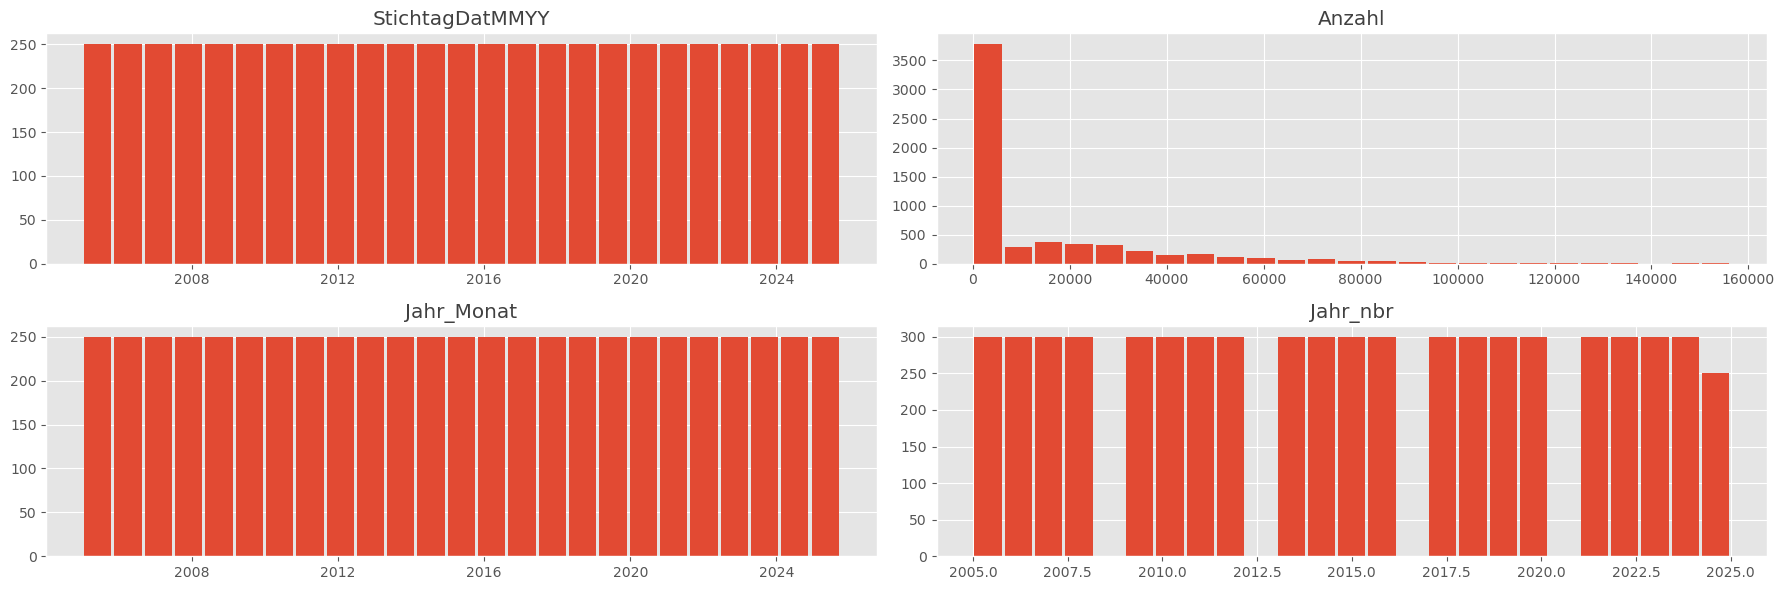

In [40]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [41]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatMMYY,Kennzahl,Sterne,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_str
Jahr_Monat_end,,,,,,,


### Nullwerte und Missings?

In [42]:
data2betested.isnull().sum()

StichtagDatMMYY     0
Kennzahl            0
Sterne              0
Anzahl             10
Jahr_Monat          0
Jahr_nbr            0
Jahr_Monat_str      0
dtype: int64

In [43]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [44]:
data2betested.reset_index().columns

Index(['Jahr_Monat_end', 'StichtagDatMMYY', 'Kennzahl', 'Sterne', 'Anzahl', 'Jahr_Monat',
       'Jahr_nbr', 'Jahr_Monat_str'],
      dtype='object')

In [45]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDatMMYY', 'Jahr_Monat_end','Jahr_Monat', 'Jahr_nbr','Jahr_Monat_str']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_end', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDatMMYY,Jahr_Monat_end,Jahr_Monat,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,2025-10-31,2025-10-01,2025,2025-10-31,582362
1,2025-09-01,2025-09-30,2025-09-01,2025,2025-09-30,613103
2,2025-08-01,2025-08-31,2025-08-01,2025,2025-08-31,679321
3,2025-07-01,2025-07-31,2025-07-01,2025,2025-07-31,651402
4,2025-06-01,2025-06-30,2025-06-01,2025,2025-06-30,625700
5,2025-05-01,2025-05-31,2025-05-01,2025,2025-05-31,608010


In [46]:
agg_kennzahl = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Kennzahl']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
agg_kennzahl.reset_index().head(6)

,Kennzahl,sum_Anz
0,Zimmer,1991356
1,Logiernächte,59484369
2,Betten,3560413
3,Betriebe,29330
4,Ankünfte,32310046


In [47]:
agg_sternen = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Sterne']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Sterne', ascending=False) 
agg_sternen.reset_index().head(6)

,Sterne,sum_Anz
0,andere Betriebe,15680379
1,5-Sterne Betriebe,12750379
2,4-Sterne Betriebe,37544656
3,3-Sterne Betriebe,21635484
4,1 und 2-Sterne Betriebe,9764616


In [48]:
agg_sternen_kz = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Sterne', 'Kennzahl']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Sterne', ascending=False) 
agg_sternen_kz.reset_index().head(6)

,Sterne,Kennzahl,sum_Anz
0,andere Betriebe,Zimmer,350456
1,andere Betriebe,Logiernächte,9739050
2,andere Betriebe,Betten,685834
3,andere Betriebe,Betriebe,9168
4,andere Betriebe,Ankünfte,4895871
5,5-Sterne Betriebe,Zimmer,272955


### Visualisierungen nach Zeitausschnitten

In [49]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6250 entries, 2005-01-31 to 2025-10-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  6250 non-null   datetime64[ns]
 1   Kennzahl         6250 non-null   object        
 2   Sterne           6250 non-null   object        
 3   Anzahl           6240 non-null   float64       
 4   Jahr_Monat       6250 non-null   datetime64[ns]
 5   Jahr_nbr         6250 non-null   int32         
 6   Jahr_Monat_str   6250 non-null   object        
dtypes: datetime64[ns](2), float64(1), int32(1), object(3)
memory usage: 495.2+ KB


In [50]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Sterne', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

#### Entwicklung der Logiernächte nach Sternen

In [72]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Sterne !="Total" and Kennzahl == "Logiernächte"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Sterne:N"
    ,category_beschriftung= 'Legende:'
    ,x_sort = None
    ,palette_scheme = None # 'turbo','viridis','category20b','category20c', 'tableau20', 'sinebow', 'rainbow, 'dark2', 'inferno',
    ,custom_palette = zuericolors_qual12
    ,line_width = 1.1 
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Logiernächte nach Sternen und Monat in der Stadt Zürich, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung der Ankünfte nach Sternen

In [52]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Sterne !="Total" and Kennzahl == "Ankünfte"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Sterne:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Ankünfte nach Sternen und Monat in der Stadt Zürich, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung der Betriebe nach Sternen

In [53]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Sterne !="Total" and Kennzahl == "Betriebe"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Sterne:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Betriebe nach Sternen und Monat in der Stadt Zürich, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung der Betten nach Sternen

In [54]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Sterne !="Total" and Kennzahl == "Betten"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Sterne:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Anazhl Betten nach Sternen und Monat in der Stadt Zürich, seit "+data_min_date
)
grafik4

alt.LayerChart(...)

#### Entwicklung der Zimmer nach Sternen

In [55]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Sterne !="Total" and Kennzahl == "Zimmer"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Sterne:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Anzahl Zimmer nach Sternen und Monat in der Stadt Zürich, seit "+data_min_date
)
grafik4

alt.LayerChart(...)

#### Faced Grids

In [56]:
sns.set_theme(style="whitegrid")

In [57]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Sterne', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [58]:
##.query('Kennzahl != "Logiernächte" and Kennzahl != "Ankünfte"') \
# .query('Kennzahl == "Logiernächte" or Kennzahl == "Ankünfte"') \
# .query('Kennzahl == "Betriebe"') \

myFG = data2betested\
    .groupby(['Jahr_nbr', 'Jahr_Monat_str','Kennzahl', 'Sterne',]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
myFG.reset_index().head(2)

,Jahr_nbr,Jahr_Monat_str,Kennzahl,Sterne,sum_Anz
0,2025,2025-10-31,Zimmer,andere Betriebe,1815
1,2023,2023-12-31,Zimmer,1 und 2-Sterne Betriebe,471


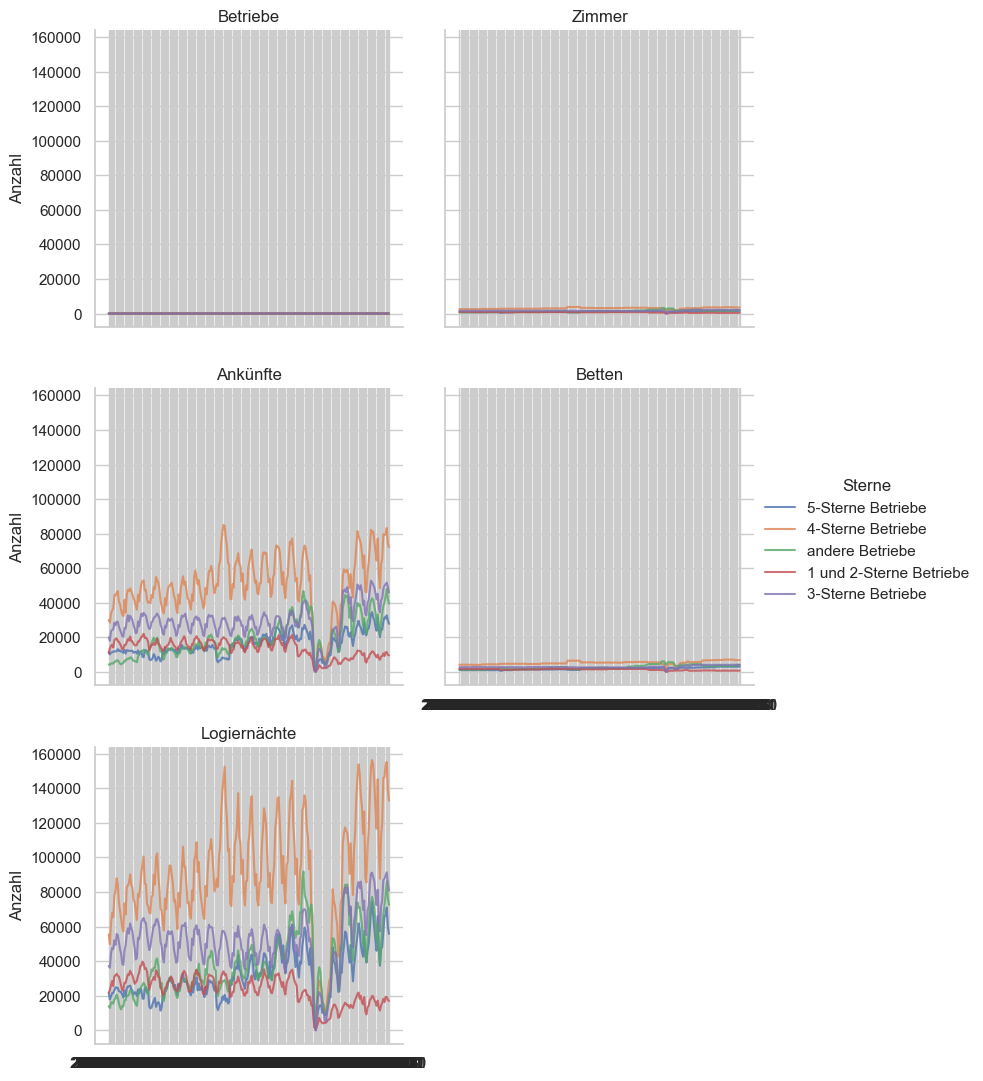

In [59]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('Jahr_Monat_str', ascending=True)
    ,col = "Kennzahl"
    ,hue = "Sterne"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_Monat_str"
    ,y = "sum_Anz"
    ,ylabel= "Anzahl"
    ,warning_status ="ignore"
    ,height = 3
    #,myTitle="Wohnbevölkerung nach Altersgruppe und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid1

##### Gibt es zeitliche Datenlücken?

In [60]:
#Gibt es eine zeitliche Datenlücke?

timefilter = "2024"
#lücke in der zeitreihe?
ideal_time_range = pd.date_range(start=data2betested.loc[timefilter].index.min(), end=data2betested.loc[timefilter].index.max(), freq='1m') #10h

# Überprüfe, ob es Unterschiede zwischen dem idealen Zeitstempelbereich und dem tatsächlichen Index gibt
missing_timestamps_my = ideal_time_range.difference(data2betested.index)

if missing_timestamps_my.empty:
    print("Keine Lücken in der Zeitreihe gefunden.")
else:
    print("Lücken in der Zeitreihe gefunden:")
    print(missing_timestamps_my)

Keine Lücken in der Zeitreihe gefunden.


### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [61]:
qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [62]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['Sterne'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '1 und 2-Sterne Betriebe': '#0017BF', 'andere Betriebe': '#0072D7', '5-Sterne Betriebe': '#00A5D2', '4-Sterne Betriebe': '#5E359A', '3-Sterne Betriebe': '#BA0062'}


#### Hotelbetriebe nach Kennzahl und Sternen

In [63]:
data2betested.reset_index().columns

Index(['Jahr_Monat_end', 'StichtagDatMMYY', 'Kennzahl', 'Sterne', 'Anzahl', 'Jahr_Monat',
       'Jahr_nbr', 'Jahr_Monat_str'],
      dtype='object')

In [64]:
myTreemapAgg = data2betested.loc["2020":data_max_date]  \
    .groupby(['StichtagDatMMYY', 'Kennzahl', 'Sterne','Jahr_Monat','Jahr_nbr', 'Jahr_Monat_str' ]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_str', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\


,StichtagDatMMYY,Kennzahl,Sterne,Jahr_Monat,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,Zimmer,andere Betriebe,2025-10-01,2025,2025-10-31,1815
1,2025-10-01,Betten,4-Sterne Betriebe,2025-10-01,2025,2025-10-31,6847
2,2025-10-01,Ankünfte,1 und 2-Sterne Betriebe,2025-10-01,2025,2025-10-31,9600
3,2025-10-01,Ankünfte,3-Sterne Betriebe,2025-10-01,2025,2025-10-31,45959


In [65]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.reset_index().query('Sterne !="Total" and Kennzahl =="Logiernächte"') \
    ,levels=['Sterne', 'Jahr_nbr',]
    ,values="sum_Anz"
    ,color="Sterne"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Logiernächte nach Sternen, "+ data_min_date + " bis "+data_max_date

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000027802E53650>, 'Sterne', 'Jahr_nbr']
Typ von path: <class 'list'>


In [66]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.reset_index().query('Sterne !="Total" and Kennzahl =="Ankünfte" or Kennzahl =="Logiernächte"') \
    ,levels=['Sterne', 'Jahr_nbr','Kennzahl']
    ,values="sum_Anz"
    ,color="Sterne"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Logiernächte und Ankünfte nach Sternen, "+ data_min_date + " bis "+data_max_date

)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x00000278038E4E90>, 'Sterne', 'Jahr_nbr', 'Kennzahl']
Typ von path: <class 'list'>


**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=458&e=kxLaJR)**